# LIBRERIAS

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.spatial import distance
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment

# Funciones

In [40]:
def plot_varianza_explicada(var_explicada, n_components):
    """
    Representa la variabilidad explicada por cada componente principal.

    Args:
        var_explicada (array): Porcentaje de varianza explicada por cada CP.
        n_components (int): Número total de componentes principales.
    """
    num_componentes_range = np.arange(1, n_components + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(num_componentes_range, var_explicada, marker='o')

    plt.xlabel('Número de Componentes Principales')
    plt.ylabel('Varianza Explicada')
    plt.title('Variabilidad Explicada por Componente Principal')
    plt.xticks(num_componentes_range)
    plt.grid(True)

    plt.bar(num_componentes_range, var_explicada, width=0.2, align='center', alpha=0.7)
    plt.show()


def plot_cos2_bars(cos2):
    """
    Gráfico de barras de la suma de cos² por variable.

    Args:
        cos2 (pd.DataFrame): Cos² por variable y componente.
    """
    plt.figure(figsize=(8, 6))
    sns.barplot(x=cos2.sum(axis=1), y=cos2.index, color="blue")

    plt.xlabel('Suma de los $cos^2$')
    plt.ylabel('Variables')
    plt.title('Varianza explicada por cada variable (cos²)')
    plt.show()

def plot_corr_circle(correlaciones_datos_con_cp):
    """
    Dibuja el círculo de correlaciones (Correlation Circle) usando CP1 y CP2.

    Parámetros:
        correlaciones_datos_con_cp: DataFrame donde las filas son variables
        y las columnas son componentes principales (al menos CP1 y CP2).
    """

    # Extraer correlaciones con CP1 y CP2
    cp1 = correlaciones_datos_con_cp.iloc[:, 0]
    cp2 = correlaciones_datos_con_cp.iloc[:, 1]

    # Intensidad según la norma del vector (o usa cp1**2+cp2**2 si prefieres cos²)
    intensidad = np.sqrt(cp1**2 + cp2**2)

    # Configurar figura
    fig, ax = plt.subplots(figsize=(8, 8))

    # Dibujar círculo unidad
    circle = plt.Circle((0, 0), 1, fill=False, color='black', linestyle='--')
    ax.add_patch(circle)

    # Mapa de colores
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(0, 1)  # 0=azul, 1=rojo

    # Dibujar flechas
    for var, x, y, inten in zip(correlaciones_datos_con_cp.index, cp1, cp2, intensidad):
        color = cmap(norm(inten))
        ax.arrow(0, 0, x, y,
                 color=color,
                 alpha=0.9,
                 length_includes_head=True,
                 head_width=0.03)
        ax.text(x, y, var, fontsize=12, color=color, ha='center', va='center')

    # Ejes
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

    # Límites
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    ax.set_xlabel("CP1 (correlación)")
    ax.set_ylabel("CP2 (correlación)")
    ax.set_title("Círculo de Correlaciones PCA")

    # Colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    plt.colorbar(sm, ax=ax, label="Intensidad de correlación (norma)")

    ax.set_aspect('equal')
    plt.show()

def plot_pca_scatter(pca, datos_estandarizados, n_components):
    """
    Gráficos de observaciones en pares de componentes principales.
    """
    componentes = pca.transform(datos_estandarizados)

    for i in range(n_components):
        for j in range(i + 1, n_components):

            plt.figure(figsize=(8, 6))
            plt.scatter(componentes[:, i], componentes[:, j])

            for k, etiqueta in enumerate(datos_estandarizados.index):
                plt.annotate(etiqueta, (componentes[k, i], componentes[k, j]))

            plt.axhline(0, color='black', linestyle='--')
            plt.axvline(0, color='black', linestyle='--')

            plt.xlabel(f'Componente {i + 1}')
            plt.ylabel(f'Componente {j + 1}')
            plt.title('PCA – Observaciones')
            plt.show()

def clustering_accuracy(y_true, y_pred):
    """
    Calcula el accuracy del clustering teniendo en cuenta
    que las etiquetas pueden estar en diferente orden.
    Usa el algoritmo húngaro para encontrar la mejor asignación.
    """
    # Convertir especies a números
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_true_enc = le.fit_transform(y_true)
    
    # Matriz de contingencia
    n_clusters = len(np.unique(y_pred))
    n_classes = len(np.unique(y_true_enc))
    contingency = np.zeros((n_clusters, n_classes), dtype=int)
    
    for i, j in zip(y_pred, y_true_enc):
        contingency[i, j] += 1
    
    # Algoritmo húngaro para máximo matching
    row_ind, col_ind = linear_sum_assignment(-contingency)
    
    correct = contingency[row_ind, col_ind].sum()
    total = len(y_true)
    
    return correct / total, contingency

# EDA

**Carga de Datos**

In [4]:
df = sns.load_dataset("penguins")

df = df.dropna()

df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Ya el dataset se encuentra listo para comenzar el analisis. Visualizamos las primeras 5 observaciones

In [5]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Estadísticos de las variables numéricas**

In [6]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [7]:
variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [8]:
# Calcula las estadísticas descriptivas para cada variable y crea un DataFrame con los resultados.
estadisticos = pd.DataFrame({
    'Mínimo': df[variables].min(),
    'Percentil 25': df[variables].quantile(0.25),
    'Mediana': df[variables].median(),
    'Percentil 75': df[variables].quantile(0.75),
    'Media': df[variables].mean(),
    'Máximo': df[variables].max(),
    'Desviación Estándar': df[variables].std(),
    'Varianza': df[variables].var(),
    'Coeficiente de Variación': (df[variables].std() / df[variables].mean()),
    'Datos Perdidos': df[variables].isna().sum()  
})
display(estadisticos.style.format("{:.2f}"))

,Mínimo,Percentil 25,Mediana,Percentil 75,Media,Máximo,Desviación Estándar,Varianza,Coeficiente de Variación,Datos Perdidos
bill_length_mm,32.10,39.50,44.50,48.60,43.99,59.60,5.47,29.91,0.12,0.00
bill_depth_mm,13.10,15.60,17.30,18.70,17.16,21.50,1.97,3.88,0.11,0.00
flipper_length_mm,172.00,190.00,197.00,213.00,200.97,231.00,14.02,196.44,0.07,0.00
body_mass_g,2700.00,3550.00,4050.00,4775.00,4207.06,6300.00,805.22,648372.49,0.19,0.00


Las medidas corporales de los pingüinos son relativamente estables (especialmente las aletas), mientras que la masa corporal es la característica más variable entre individuos, lo que tiene sentido biológicamente dado que depende de factores como especie, sexo y estación del año.

**Analisis de dispersión**

PAIRPLOT para visualizar scatter plots entre todas las variables numéricas

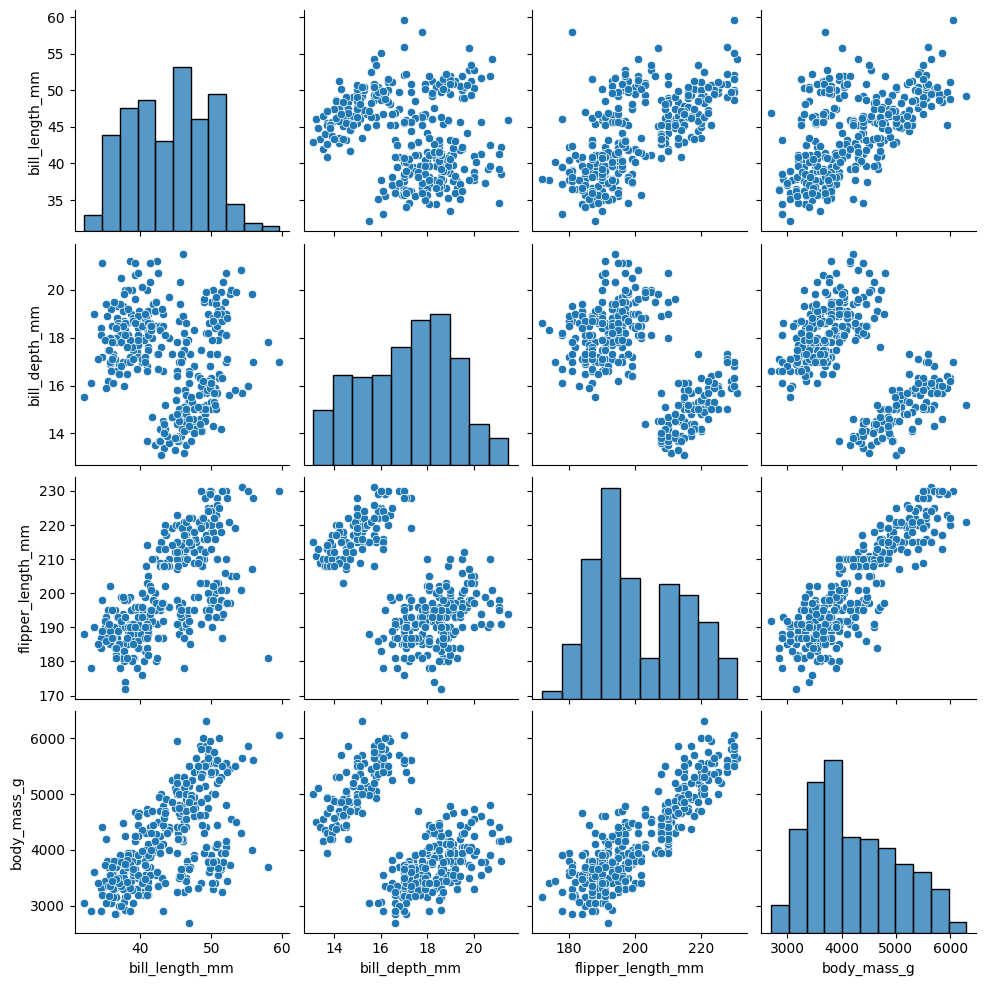

In [11]:
sns.pairplot(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']])

**Matriz de Correlaciones**

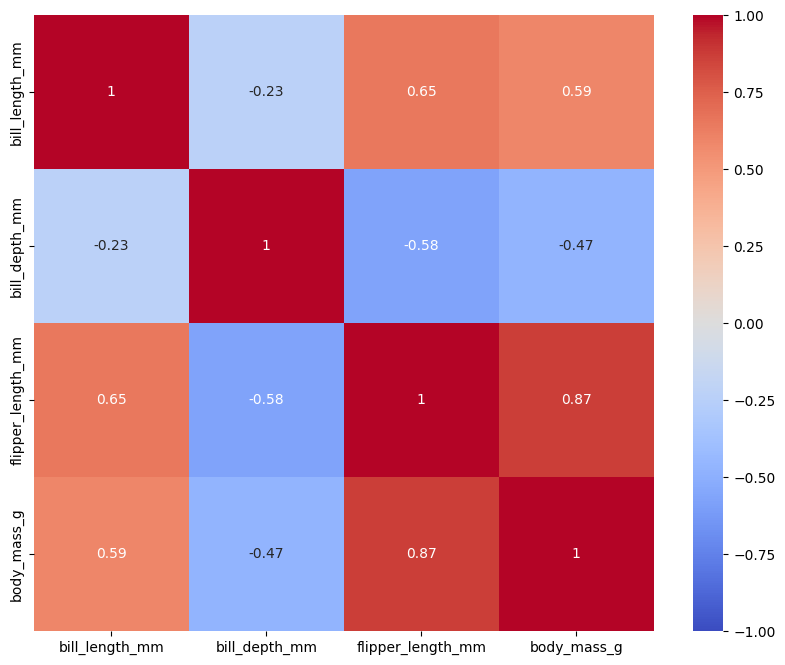

In [12]:
# --- Pearson ---
corr_pearson = df[variables].corr(method='pearson')

# Visualización
plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

**`bill_depth_mm`** es la única variable con correlación negativa con todas las demás. La correlación inversa más fuerte es con `flipper_length_mm` (r = −0.58), seguida de `body_mass_g` (r = −0.47) y `bill_length_mm` (r = −0.23). Por otro lado, `flipper_length_mm` y `body_mass_g` presentan la correlación positiva más alta (r = 0.87), ambas como indicadores del tamaño corporal general. Cabe destacar que estas correlaciones negativas globales responden a la **Paradoja de Simpson**: la especie Gentoo, con picos poco profundos pero cuerpos grandes y aletas largas, distorsiona las correlaciones al analizar el dataset sin distinguir por especie.

El tamaño corporal general (aleta + masa + pico largo) es el patrón dominante, pero las diferencias entre especies invierten algunas correlaciones cuando se analiza el dataset completo sin distinguirlas.

# PCA

### Estandarizamos los datos

In [ ]:
datos_para_escalar = df[variables].dropna() 
scaler = StandardScaler()
datos_std_scaled = scaler.fit_transform(datos_para_escalar)

datos_std = pd.DataFrame(
    datos_std_scaled,  
    columns=['{}_z'.format(col) for col in variables],  
    index=datos_para_escalar.index  
)
display(datos_std.style.format("{:.2f}"))

,bill_length_mm_z,bill_depth_mm_z,flipper_length_mm_z,body_mass_g_z
0,-0.90,0.78,-1.43,-0.57
1,-0.82,0.12,-1.07,-0.51
2,-0.68,0.42,-0.43,-1.19
4,-1.34,1.09,-0.57,-0.94
5,-0.86,1.75,-0.78,-0.69
6,-0.93,0.32,-1.43,-0.72
7,-0.88,1.24,-0.43,0.58
12,-0.53,0.22,-1.36,-1.25
13,-0.99,2.05,-0.71,-0.51
14,-1.72,2.00,-0.21,0.24


**PCA**

In [14]:
pca = PCA(n_components=4)


fit = pca.fit(datos_std)
display(fit)

autovalores = fit.explained_variance_

var_explicada = fit.explained_variance_ratio_*100


,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [15]:
# Calcular la varianza explicada acumulada a medida que se agregan cada componente principal.
var_acumulada = np.cumsum(var_explicada)

# Crear un DataFrame de pandas con los datos anteriores y establecer índice.
data = {'Autovalores': autovalores, 'Variabilidad Explicada': var_explicada, 'Variabilidad Acumulada': var_acumulada}
tabla = pd.DataFrame(data, index=['Componente {}'.format(i) for i in range(1, fit.n_components_+1)])

# Imprimir la tabla
display(tabla.style.format("{:.2f}"))

,Autovalores,Variabilidad Explicada,Variabilidad Acumulada
Componente 1,2.75,68.63,68.63
Componente 2,0.78,19.45,88.09
Componente 3,0.37,9.22,97.30
Componente 4,0.11,2.70,100.00


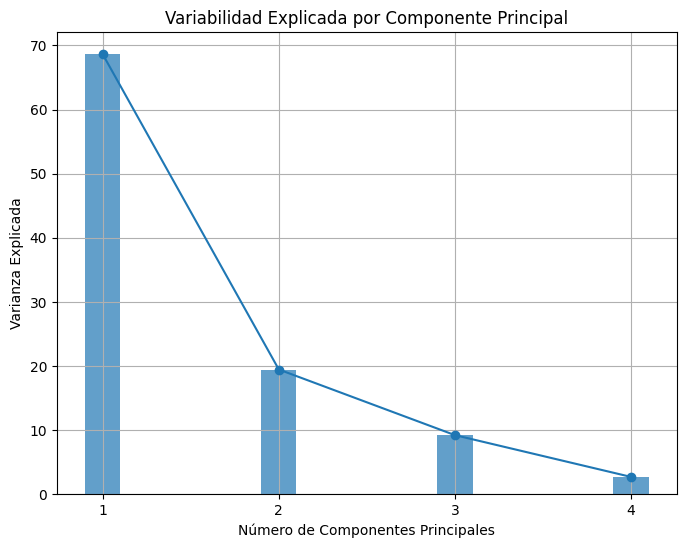

In [16]:
plot_varianza_explicada(var_explicada, fit.n_components_)

el número adecuado de componentes para representar eficientemente la variabilidad de las especies de pingüinos es 2, ya que con CP1 y CP2 se captura el 86.24% de la información total del dataset


In [17]:
# Crea una instancia de ACP con las dos primeras componentes que nos interesan y aplicar a los datos.
pca = PCA(n_components=2)
fit = pca.fit(datos_std)

# Obtener los autovalores asociados a cada componente principal.
autovalores = fit.explained_variance_

# Obtener los autovectores asociados a cada componente principal y transponerlos.
autovectores = pd.DataFrame(pca.components_.T,
                            columns = ['Autovector {}'.format(i) for i in range(1, fit.n_components_+1)],
                            index = ['{}_z'.format(variable) for variable in variables])
display(autovectores.style.format("{:.2f}"))

,Autovector 1,Autovector 2
bill_length_mm_z,0.45,0.60
bill_depth_mm_z,-0.40,0.80
flipper_length_mm_z,0.58,0.01
body_mass_g_z,0.55,0.08


Estos serian los pesos que le da cada componente a cada variable - nos dice que qué variables son + importantes

In [46]:
# Calculamos las dos primeras componentes principales
resultados_pca = pd.DataFrame(fit.transform(datos_std),
                              columns=['Componente {}'.format(i) for i in range(1, 3)],
                              index=datos_std.index)

# Concatenamos las componentes principales a la base de datos estandarizada.
datos_z_cp = pd.concat([datos_std, resultados_pca], axis=1)
display(datos_z_cp.style.format("{:.2f}"))

,bill_length_mm_z,bill_depth_mm_z,flipper_length_mm_z,body_mass_g_z,Componente 1,Componente 2
0,-0.90,0.78,-1.43,-0.57,-1.85,0.03
1,-0.82,0.12,-1.07,-0.51,-1.32,-0.44
2,-0.68,0.42,-0.43,-1.19,-1.38,-0.16
4,-1.34,1.09,-0.57,-0.94,-1.89,-0.01
5,-0.86,1.75,-0.78,-0.69,-1.92,0.82
6,-0.93,0.32,-1.43,-0.72,-1.77,-0.37
7,-0.88,1.24,-0.43,0.58,-0.82,0.50
12,-0.53,0.22,-1.36,-1.25,-1.80,-0.25
13,-0.99,2.05,-0.71,-0.51,-1.96,1.00
14,-1.72,2.00,-0.21,0.24,-1.57,0.58


In [47]:
# Cálculo de las correlaciones entre las variables originales y las componentes seleccionadas.
# Guardamos el nombre de las variables del archivo conjunto (variables y componentes).
variables_cp = datos_z_cp.columns

# Calculamos las correlaciones y seleccionamos las que nos interesan (variables contra componentes).
correlacion = pd.DataFrame(np.corrcoef(datos_std.T, resultados_pca.T),
                           index = variables_cp, columns = variables_cp)

n_variables = fit.n_features_in_
correlaciones_datos_con_cp = correlacion.iloc[:fit.n_features_in_, fit.n_features_in_:]
display(correlaciones_datos_con_cp.style.format("{:.2f}"))

,Componente 1,Componente 2
bill_length_mm_z,0.75,0.53
bill_depth_mm_z,-0.66,0.70
flipper_length_mm_z,0.96,0.01
body_mass_g_z,0.91,0.07


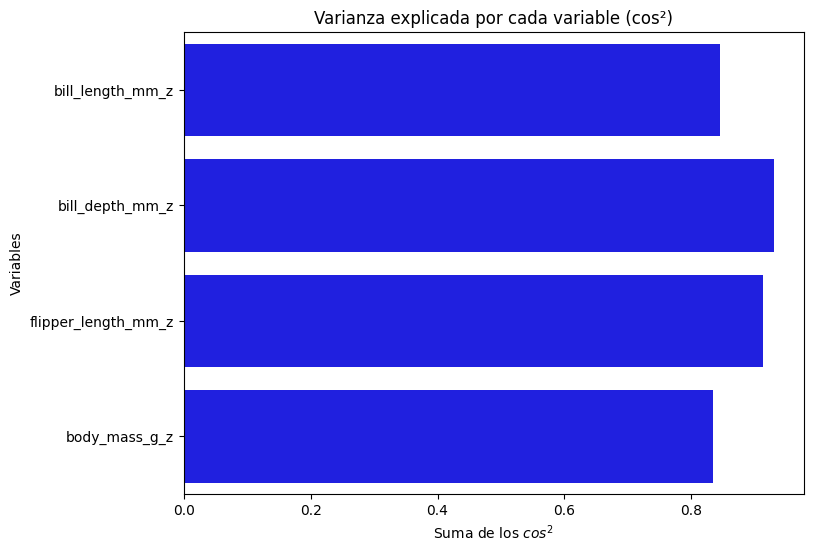

In [48]:
cos2 = correlaciones_datos_con_cp **2
plot_cos2_bars (cos2)

Las 4 variables presentan cos² superior a 0.80, lo que confirma que el plano CP1-CP2 representa adecuadamente toda la información original sin pérdidas relevantes.

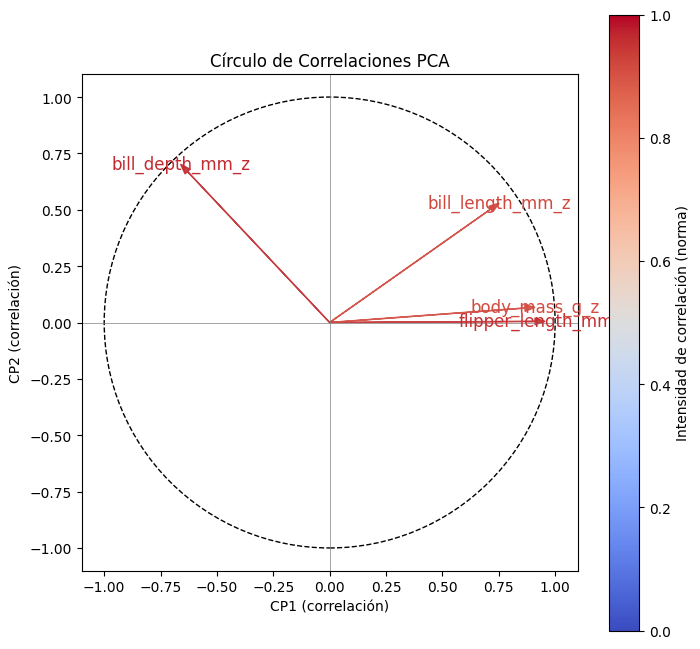

In [49]:
plot_corr_circle(correlaciones_datos_con_cp)

CP1 recoge el tamaño corporal general (flipper y body_mass positivos, bill_depth negativo).
CP2 captura la morfología del pico (bill_length dominante).
Todas las flechas son largas, confirmando buena representación de todas las variables.

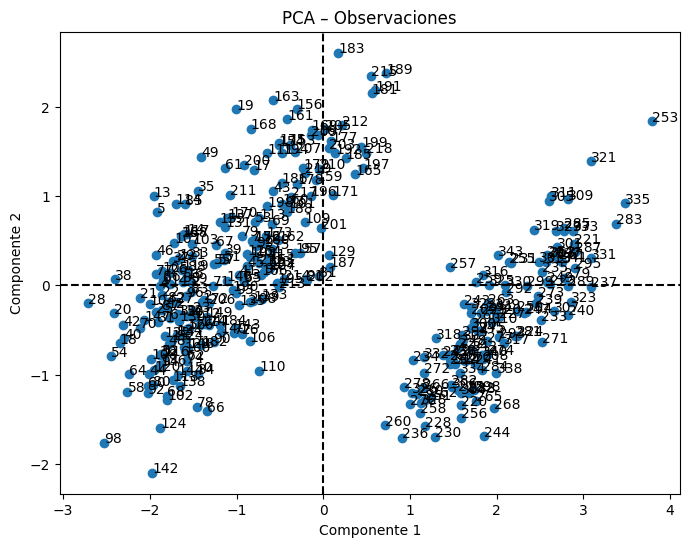

In [50]:
plot_pca_scatter (pca, datos_std, fit.n_components)

Se aprecian dos nubes separadas a lo largo de CP1: pingüinos pequeños (izquierda)
y grandes (derecha). Sin embargo, sin color no es posible identificar las especies.

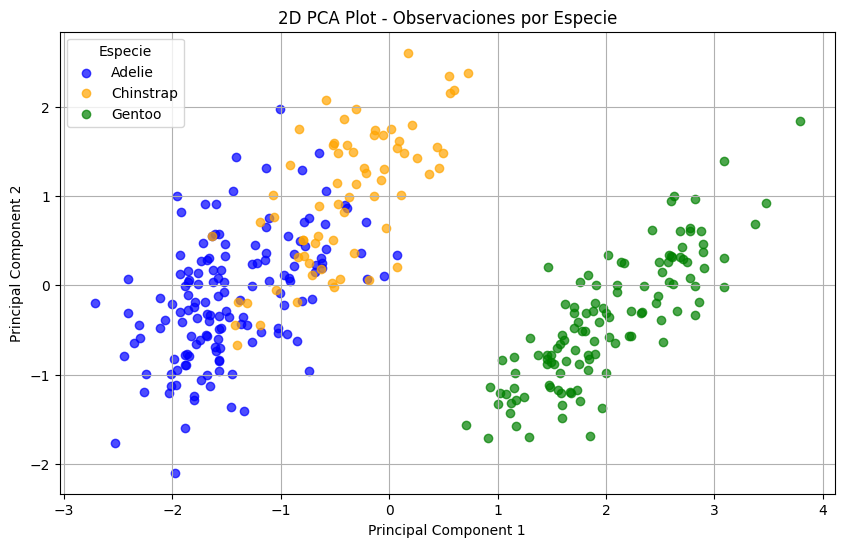

In [18]:
# Step 1: Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(datos_std)

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Añadir columna de especie alineada con datos_std
df_pca['species'] = df.loc[datos_std.index, 'species'].values

# Step 2: Colores por especie
colores = {'Adelie': 'blue', 'Chinstrap': 'orange', 'Gentoo': 'green'}

plt.figure(figsize=(10, 6))

for especie, grupo in df_pca.groupby('species'):
    plt.scatter(grupo['PC1'], grupo['PC2'],
                label=especie,
                color=colores[especie],
                alpha=0.7)

plt.title("2D PCA Plot - Observaciones por Especie")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Especie')
plt.grid()
plt.show()

Gentoo (verde) se separa claramente en CP1 por su mayor tamaño corporal.
Adelie (azul) y Chinstrap (naranja) se separan en CP2 por la morfología del pico.
El PCA logra distinguir las 3 especies sin haber usado las etiquetas en ningún momento.

# CLUSTERING

MATRIZ DE DISTANCIAS

In [19]:
species_labels = df.loc[datos_std.index, 'species']

# Calcula las distancias euclidianas por pares utilizando los datos numéricos estandarizados.
distance_matrix = distance.cdist(datos_std, datos_std, 'euclidean')


print("Matriz de Distancia (primeras 5x5 filas/columnas, redondeado):")
distance_small = distance_matrix[:5, :5]


distance_small = pd.DataFrame(distance_small, index=datos_std.index[:5], columns=datos_std.index[:5])

distance_small_rounded = distance_small.round(2)
distance_small_rounded = distance_small_rounded.reset_index(drop=True)
distance_small_rounded.columns = range(len(distance_small_rounded.columns))
print(distance_small_rounded)

Matriz de Distancia (primeras 5x5 filas/columnas, redondeado):
      0     1     2     3     4
0  0.00  0.76  1.25  1.08  1.17
1  0.76  0.00  1.00  1.28  1.66
2  1.25  1.00  0.00  0.98  1.47
3  1.08  1.28  0.98  0.00  0.88
4  1.17  1.66  1.47  0.88  0.00


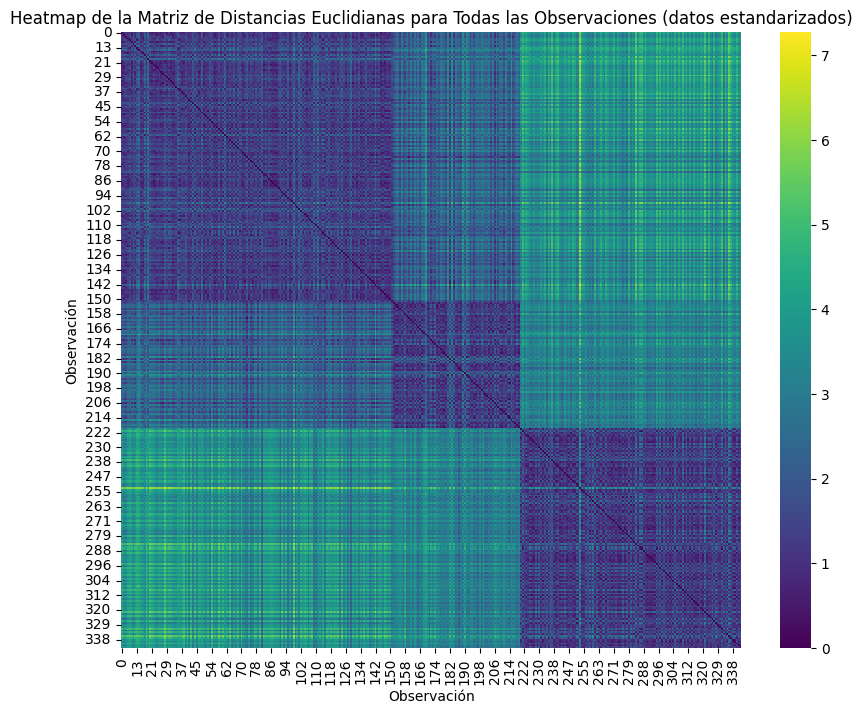

In [20]:
plt.figure(figsize=(10, 8))
df_distance = pd.DataFrame(distance_matrix, index = df.index, columns = df.index)
sns.heatmap(df_distance, annot=False, cmap="viridis", fmt=".2f")
plt.title("Heatmap de la Matriz de Distancias Euclidianas para Todas las Observaciones (datos estandarizados)")
plt.xlabel("Observación")
plt.ylabel("Observación")
plt.show()

El heatmap revela 3 bloques oscuros bien definidos en la diagonal, lo que indica
la existencia de 3 grupos naturales con alta similitud interna. Las zonas claras
fuera de la diagonal confirman que los grupos son morfológicamente distintos entre sí,
anticipando que k=3 será el número óptimo de clusters.

Dendograma

C:\Users\Dayron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\Dayron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
C:\Users\Dayron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\Dayron\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_q

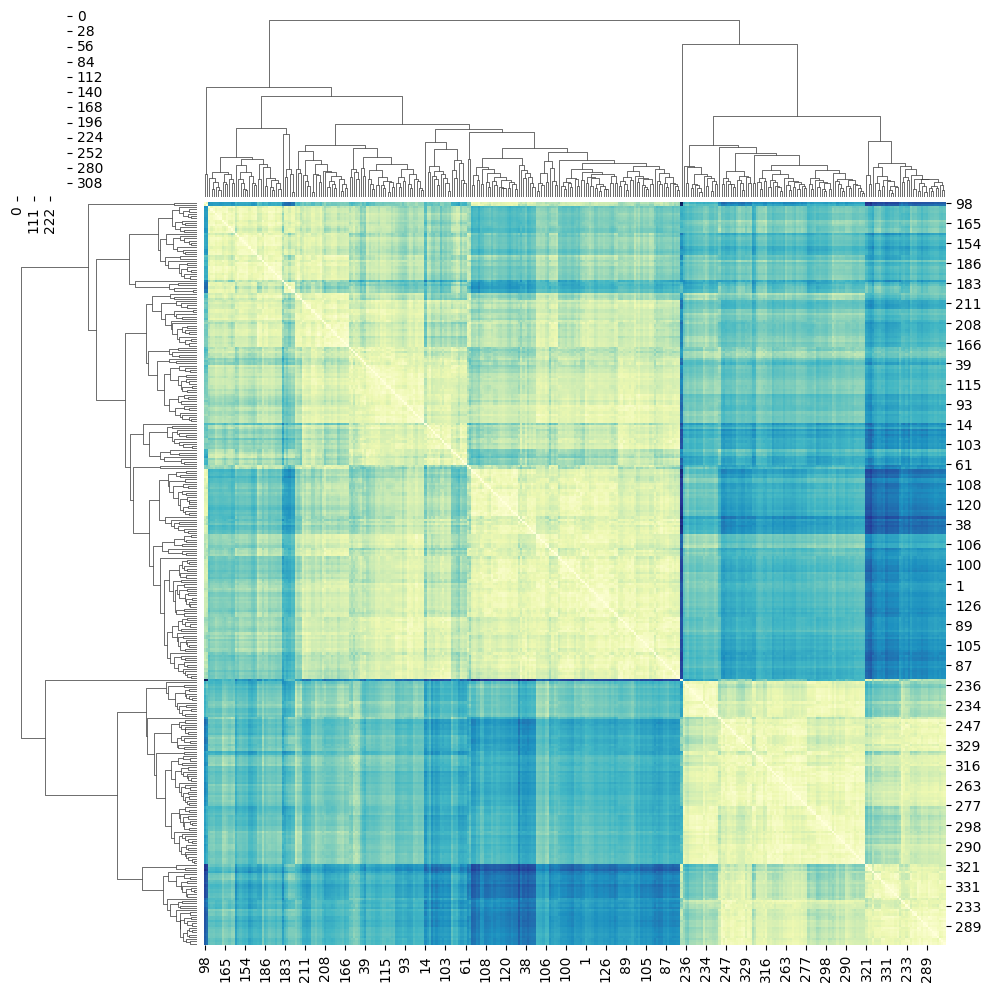

In [21]:
# Perform hierarchical clustering to get the linkage matrix
linkage = sns.clustermap(df_distance, cmap="YlGnBu", fmt=".1f", annot=False, method='average').dendrogram_row.linkage

# Reorder the data based on the hierarchical clustering
order = pd.DataFrame(linkage, columns=['cluster_1', 'cluster_2', 'distance', 'new_count']).index
reordered_data = df.reindex(index=order, columns=order)

# Optionally, you can add color bar
sns.heatmap(reordered_data, cmap="YlGnBu", fmt=".1f", cbar=False)
plt.show()

El heatmap jerárquico reordena las observaciones según el agrupamiento por enlace
promedio, revelando 3 bloques compactos en la diagonal con alta similitud interna
(color amarillo) y grandes diferencias entre grupos (color azul oscuro).
Esto confirma visualmente que k=3 es el número natural de clusters en el dataset.

Dendrograma — Clustering Jerárquico (Ward)

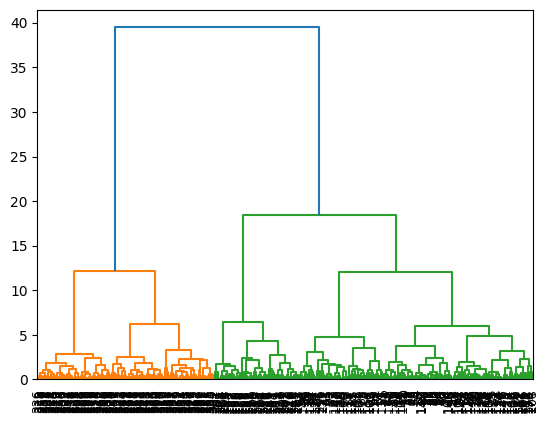

In [22]:
# Calculate the linkage matrix
linkage_matrix = sch.linkage(datos_std, method='ward')  # You can choose a different linkage method if needed

# Create the dendrogram
dendrogram = sch.dendrogram(linkage_matrix, labels=df.index, leaf_font_size=9, leaf_rotation=90)

# Display the dendrogram
plt.show()

El dendrograma (Ward) muestra 2 ramas principales unidas a altura ~40, el salto
más grande del árbol. La rama derecha se subdivide a altura ~18, revelando
3 grupos naturales. Cortando por debajo del salto más pronunciado se obtiene
k=3, decisión coherente con la estructura biológica real del dataset (3 especies).

Nos quedamos con 3 cluster

In [23]:
num_clusters = 3
cluster_assignments = sch.fcluster(linkage_matrix, num_clusters, criterion='maxclust')

# Display the cluster assignments
print("Cluster Assignments:", cluster_assignments)

# Display the dendrogram
plt.show()

Cluster Assignments: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2
 2 2 2 2 3 2 3 2 2 2 2 2 2 2 2 2 2 2 3 2 3 2 2 2 2 2 2 2 3 2 3 2 2 2 2 2 3
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 3 2 2 3 2 2 2 2 3 2 2 2 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


añadimos la nueva variable al df

In [24]:
# Create a new column 'Cluster' and assign the 'cluster_assignments' values to it
df['Cluster3'] = cluster_assignments

# Now 'df' contains a new column 'Cluster' with the cluster assignments

print(df["Cluster3"])

0      3
1      3
2      3
4      3
5      3
      ..
338    1
340    1
341    1
342    1
343    1
Name: Cluster3, Length: 333, dtype: int32


Se fijan 3 clusters usando fcluster() con criterio 'maxclust', que corta el dendrograma
para obtener exactamente k=3 grupos. Las asignaciones se almacenan en una nueva
columna 'Cluster3' del DataFrame original, permitiendo relacionar cada pingüino
con su cluster para los análisis posteriores.

# Representación de los datos y su pertenencia a los clusters

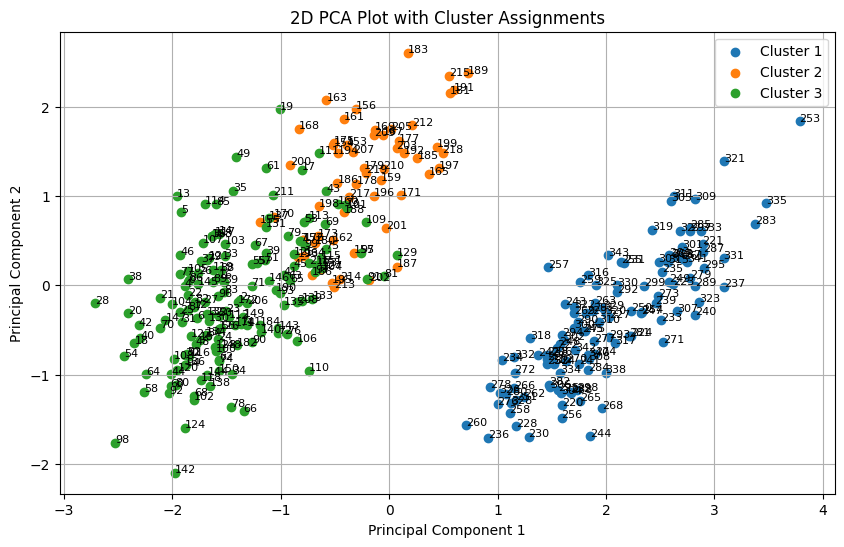

In [25]:
# Assuming 'df' is your original DataFrame with data
# 'cluster_assignments' contains cluster assignments

# Step 1: Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(datos_std)

# Create a new DataFrame for the 2D principal components
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(cluster_assignments):
    plt.scatter(df_pca.loc[cluster_assignments == cluster, 'PC1'],
                df_pca.loc[cluster_assignments == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(df.index[i]), fontsize=8)

plt.title("2D PCA Plot with Cluster Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

Se proyectan los clusters jerárquicos sobre el plano PCA (CP1 vs CP2) para
visualizar espacialmente la separación entre grupos.
Cluster 1 (azul) → pingüinos grandes, valores altos en CP1 (Gentoo)
Cluster 2 (naranja) → pico morfológicamente distinto, valores altos en CP2 (Chinstrap)
Cluster 3 (verde) → pingüinos pequeños, valores negativos en CP1 (Adelie)
La separación entre clusters es clara, validando visualmente el agrupamiento jerárquico.

# Clustering No Jerárquico

# K-Means


Probar varios k para sacar el mejor (metodo del codo)

In [27]:

#Create an array to store the WCSS values for different values of K:
wcss = []

for k in range(1, 11):  # You can choose a different range of K values
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(datos_std)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS value

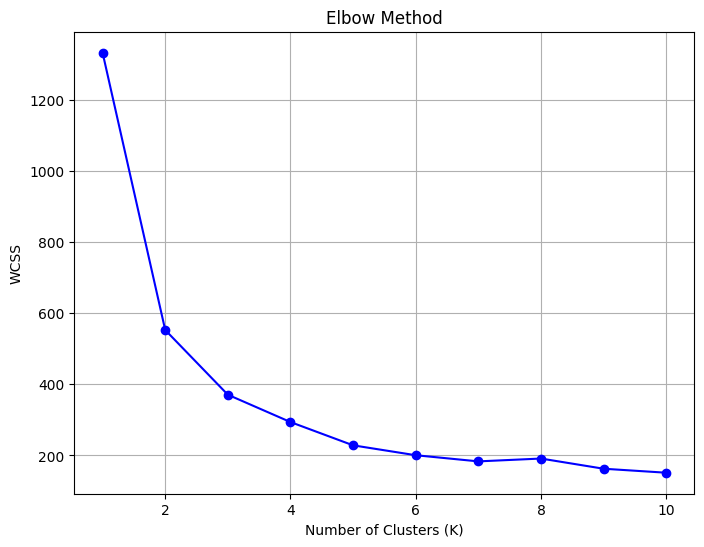

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

El método del codo calcula el WCSS (varianza interna) para k=1 a k=10.
Se observa una caída brusca hasta k=3 y luego la curva se aplana progresivamente.
El "codo" se sitúa en k=3, punto a partir del cual añadir más clusters
no reduce significativamente el WCSS → k=3 es el número óptimo de grupos.

K-MEANS


Distribución de clusters: 0     85
1    119
2    129
Name: count, dtype: int64


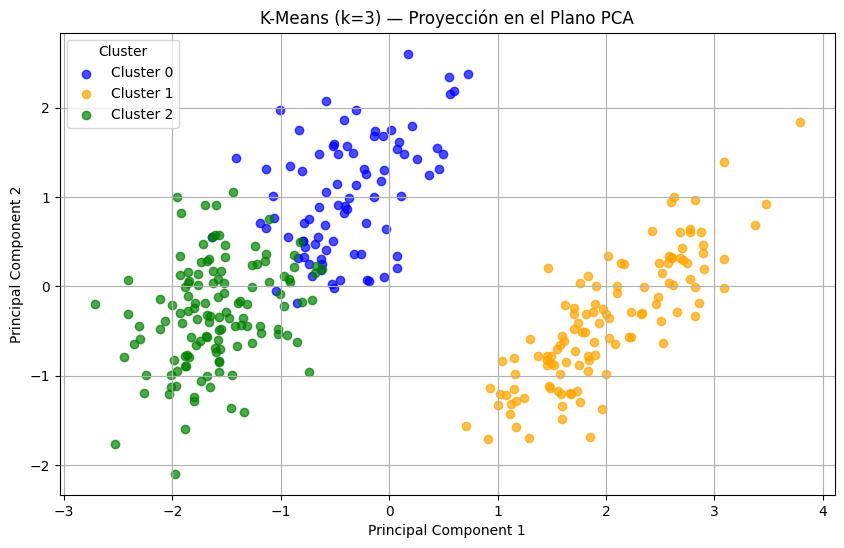

In [29]:
# Inicializar y ajustar el modelo K-Means con k=3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(datos_std)

# Obtener las etiquetas de cluster
kmeans_labels = kmeans.labels_
print("Distribución de clusters:", pd.Series(kmeans_labels).value_counts().sort_index())

# Añadir etiquetas al DataFrame original
df['kmeans_label'] = kmeans_labels

# PROYECCIÓN EN EL PLANO PCA

# PCA 2 componentes (ya calculado anteriormente)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Colores por cluster
colores = {0: 'blue', 1: 'orange', 2: 'green'}

plt.figure(figsize=(10, 6))

for cluster in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster
    plt.scatter(df_pca.loc[mask, 'PC1'],
                df_pca.loc[mask, 'PC2'],
                label=f'Cluster {cluster}',
                color=colores[cluster],
                alpha=0.7)

plt.title("K-Means (k=3) — Proyección en el Plano PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid()
plt.show()

K-Means con k=3 produce una separación muy similar al clustering jerárquico.
Cluster 0 (azul) → pingüinos pequeños, CP1 negativo (Adelie + Chinstrap)
Cluster 1 (naranja) → pingüinos grandes, CP1 positivo (Gentoo)
Cluster 2 (verde) → grupo minoritario en el extremo inferior izquierdo
La estructura es coherente con el jerárquico.

MÉTRICAS DE VALIDACIÓN

Gráfico de Silueta

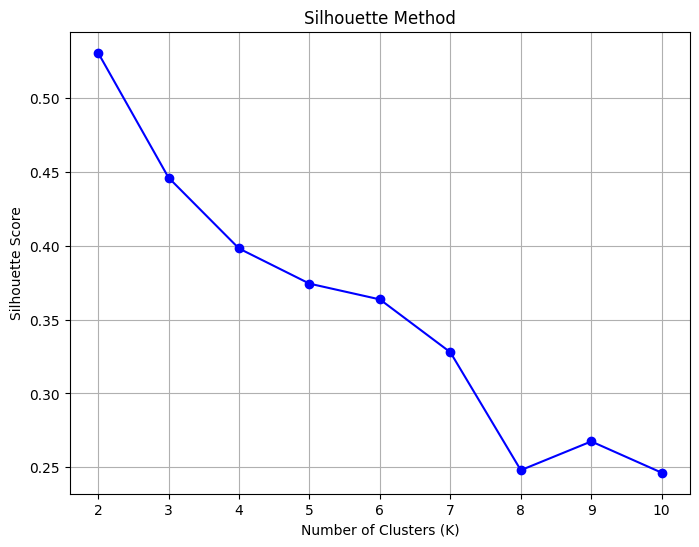

In [30]:
#Create an array to store silhouette scores for different values of K

silhouette_scores = []

#Run K-means clustering for a range of K values and calculate the silhouette score for each K:

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(datos_std)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(datos_std, labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

Silhouette por k:
El score más alto se obtiene en k=2 (≈0.53), pero k=3 (≈0.45) es el valor
más razonable considerando el contexto biológico y los resultados anteriores.
A partir de k=3 el score decrece progresivamente, confirmando que k=3
es el equilibrio óptimo entre calidad del clustering y número de grupos.

In [31]:
# Assuming 'df_std_distance' is your standardized data and '3' is the optimal number of clusters
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(datos_std)
labels = kmeans.labels_

In [32]:
silhouette_values = silhouette_samples(datos_std, labels)
silhouette_values

array([ 0.48709953,  0.49109643,  0.38732019,  0.49548036,  0.28434675,
        0.52914184,  0.14043449,  0.41791818,  0.2352181 ,  0.239343  ,
        0.58636559,  0.43769413,  0.12639473,  0.56674201,  0.26815692,
        0.48359533,  0.5309068 ,  0.5227126 ,  0.5205562 ,  0.48937501,
        0.5458217 ,  0.43813374,  0.45499919,  0.44072108,  0.36704438,
        0.45060548,  0.50713838,  0.52046838,  0.35341619,  0.51746518,
        0.12845578,  0.34453111,  0.31221922,  0.49202599,  0.22615621,
        0.56138558,  0.2721957 ,  0.55397671,  0.2393409 ,  0.52813758,
        0.226963  ,  0.37537388,  0.59309188,  0.027075  ,  0.52616882,
        0.29329028,  0.58532205,  0.05064232,  0.5286541 ,  0.30441714,
        0.54680012,  0.32493605,  0.48542446,  0.47052088,  0.55396825,
        0.01930467,  0.55516107,  0.26594217,  0.51426904,  0.24311629,
        0.47431796,  0.25145277,  0.51716624,  0.05431918,  0.52677789,
        0.44017389,  0.41004901,  0.3780492 ,  0.57212919,  0.05

C:\Users\Dayron\AppData\Local\Temp\ipykernel_20440\3680482490.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / 4)


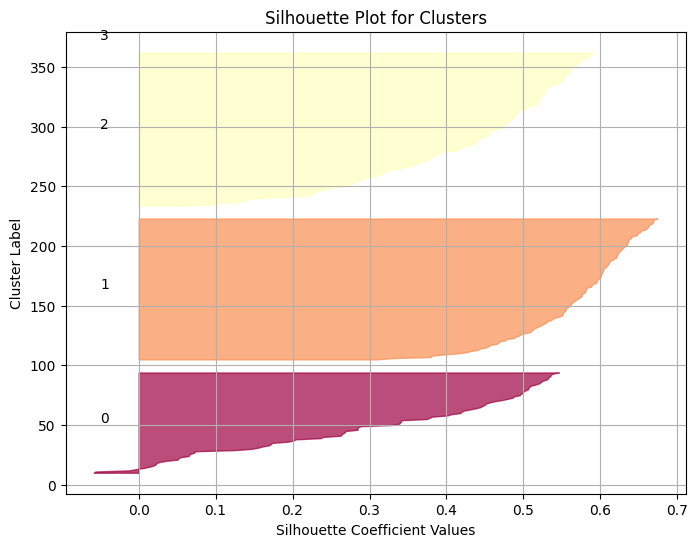

In [33]:
plt.figure(figsize=(8, 6))

y_lower = 10
for i in range(4):
    ith_cluster_silhouette_values = silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.get_cmap("Spectral")(float(i) / 4)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title("Silhouette Plot for Clusters")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.grid(True)
plt.show()

Silhouette plot (k=3):
Cluster 1 (naranja) es el más grande y compacto, con valores altos y uniformes.
Cluster 2 (amarillo) muestra buena cohesión aunque con mayor variabilidad.
Cluster 0 (morado) es el más pequeño y presenta algunos valores negativos,
indicando que ciertos pingüinos están mal asignados o en la frontera entre clusters.

Tabla para comparar resultados

In [37]:
# Comparación clusters K-Means vs especies reales
comparacion = pd.crosstab(df['kmeans_label'], df['species'])
print(comparacion)

species       Adelie  Chinstrap  Gentoo
kmeans_label                           
0                 22         63       0
1                  0          0     119
2                124          5       0


Cluster 1 → Gentoo puro (119/119, 100% de precisión)
Cluster 2 → Adelie casi puro (124/129, 96% de precisión)
Cluster 0 → Chinstrap casi puro (63/85, 74% de precisión)
La mayor confusión se da entre Adelie y Chinstrap, especies morfológicamente
similares en tamaño que solo se separan bien en CP2 (morfología del pico).

Comparativa  Jerarquico versus K-Means

In [38]:
comparacion_jerarquico = pd.crosstab(df['Cluster3'], df['species'])
print(comparacion_jerarquico)

species   Adelie  Chinstrap  Gentoo
Cluster3                           
1              0          0     119
2              0         57       0
3            146         11       0


In [41]:
# ============================================================
# ACCURACY JERÁRQUICO
# ============================================================
acc_jer, cont_jer = clustering_accuracy(df['species'], df['Cluster3'] - 1)
print(f"Accuracy Clustering Jerárquico: {acc_jer*100:.2f}%")

# ============================================================
# ACCURACY K-MEANS
# ============================================================
acc_km, cont_km = clustering_accuracy(df['species'], df['kmeans_label'])
print(f"Accuracy K-Means:               {acc_km*100:.2f}%")

# ============================================================
# RESUMEN COMPARATIVO
# ============================================================
resumen = pd.DataFrame({
    'Método': ['Jerárquico (Ward)', 'K-Means (k=3)'],
    'Accuracy (%)': [round(acc_jer*100, 2), round(acc_km*100, 2)],
    'Errores': [333 - round(acc_jer*333), 333 - round(acc_km*333)]
})
print("\n=== COMPARACIÓN DE MÉTODOS ===")
print(resumen.to_string(index=False))

Accuracy Clustering Jerárquico: 96.70%
Accuracy K-Means:               91.89%

=== COMPARACIÓN DE MÉTODOS ===
           Método  Accuracy (%)  Errores
Jerárquico (Ward)         96.70       11
    K-Means (k=3)         91.89       27


Jerárquico (Ward): 96.70% de accuracy, solo 11 errores de 333 observaciones.
K-Means (k=3):     91.89% de accuracy, 27 errores de 333 observaciones.
Ambos métodos son altamente efectivos, pero el jerárquico supera a K-Means
en 16 asignaciones correctas adicionales, siendo más preciso en este dataset.

CENTROIDES DE LOS CLUSTERS
Datos estandarizados y datos originales

In [34]:
# Add the labels as a new column to the DataFrame
datos_std['label'] = labels
# Sort the DataFrame by the "label" column
datos_std_sort = datos_std.sort_values(by="label")
# Set the 'A' column as the index
datos_std = datos_std.reset_index(drop = True)
datos_std_sort['label']

43    0
49    0
53    0
61    0
69    0
     ..
52    2
37    2
38    2
39    2
0     2
Name: label, Length: 333, dtype: int32

In [42]:
# Group the data by the 'label' column and calculate the mean of each group
cluster_centroids = datos_std_sort.groupby('label').mean()
cluster_centroids.round(2)
# 'cluster_centroids' now contains the centroids of each cluster

,bill_length_mm_z,bill_depth_mm_z,flipper_length_mm_z,body_mass_g_z
label,,,,
0,0.67,0.81,-0.29,-0.38
1,0.65,-1.10,1.16,1.10
2,-1.05,0.49,-0.88,-0.76


datos originales

In [43]:
# Add the labels as a new column to the DataFrame
df['label'] = labels
# Sort the DataFrame by the "label" column
df_sort = df.sort_values(by="label")

# Group the data by the 'label' column and calculate the mean of each group
# Select only numeric columns for mean calculation
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cluster_centroids_orig = df_sort.groupby('label')[numeric_cols].mean()
cluster_centroids_orig.round(2)
# 'cluster_centroids' now contains the centroids of each cluster

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,47.66,18.75,196.92,3898.24
1,47.57,15.00,217.24,5092.44
2,38.28,18.12,188.63,3593.80


Cluster 0 → Chinstrap: pico largo (47.66mm) y profundo (18.75mm), 
             aleta media (196.92mm), masa moderada (3898g)
Cluster 1 → Gentoo: pico largo (47.57mm) y poco profundo (15.0mm),
             aleta muy larga (217.24mm), masa elevada (5092g)
Cluster 2 → Adelie: pico corto (38.28mm) y poco profundo (18.12mm),
             aleta corta (188.63mm), masa baja (3593g)